## Data-driven modelling of cooperative decision-making under resource inequality in an urban collective-risk dilemma
### Synthetic data by hypothesis and hybridisation
 - $H_0$: Probability of the next contribution based on the previous one.
 - $H_1$: Probability of the next contribution based on the previous average contribution of others.
 - $H_2$: Probability of the next contribution based on the Cumulative contribution of all players.
 - $H_3$: Probability of the next contribution based on the remaining relative coins.

In [1]:
#Register some PC Stats
%load_ext watermark
%watermark

Last updated: 2026-04-28T11:21:31.783357+02:00

Python implementation: CPython
Python version       : 3.14.3
IPython version      : 9.10.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : AMD64 Family 25 Model 124 Stepping 0, AuthenticAMD
CPU cores   : 12
Architecture: 64bit



In [26]:
#Importing all libraries needed
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib import cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from collections import defaultdict
from matplotlib.cm import ScalarMappable
from matplotlib import colors
from functions import *
import os
# Set Pandas to display all columns
pd.set_option('display.max_columns', None)
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
%matplotlib inline

In [3]:
# Load Probabilties datasets
datasets = {
    "H0": pd.read_csv("Datasets/H0_Previous_contribution.csv"),
    "H1": pd.read_csv("Datasets/H1_Others_contribution.csv"),
    "H2": pd.read_csv("Datasets/H2_Cumulative_contribution.csv"),
    "H3": pd.read_csv("Datasets/H3_Spending_coins.csv")
}
# Load real data
df_users_six = pd.read_csv("Datasets/df_users_six_players.csv")
successful_users_six = pd.read_csv("Datasets/successful_users_six.csv")

Simulations by Hypothesis and Hybridisation

In [5]:
%%time
# Create a fixed RNG seed for reproducibility
SEED = 42
# Simulate all hypothesis DataFrames
simulated_dfs = {}
for hypo in ["H0", "H1", "H2", "H3","Hybridisation"]:
    np.random.seed(SEED)
    rng = np.random.default_rng(SEED)  # Restart RNG for each hypothesis
    simulated_dfs[hypo] = simulate_games_dataframe(datasets, hypo, rng)

CPU times: total: 26.7 s
Wall time: 27.4 s


In [6]:
# Ensure the directory exists
os.makedirs("Datasets", exist_ok=True)

# Save each simulated DataFrame to a CSV in the Datasets/ folder
for hypo, df in simulated_dfs.items():
    filename = f"Datasets/df_users_{hypo}.csv"
    df.to_csv(filename, index=False)
    print(f"Saved: {filename}")

Saved: Datasets/df_users_H0.csv
Saved: Datasets/df_users_H1.csv
Saved: Datasets/df_users_H2.csv
Saved: Datasets/df_users_H3.csv
Saved: Datasets/df_users_Hybridisation.csv


### Proportion of games reaching the collective goal
Goal attainment across treatments and strategies

In [11]:
#Filter for Successful Users and computing proportion of games reaching the Goal
simulated_dfs_success = {}
proportion_ci_results = defaultdict(dict)

for hypo, df in simulated_dfs.items():
    successful = df[df["goal_reached"] == 1].copy()
    successful['normalized_payoff'] = successful['endowment_current'] / (0.5 * successful['endowment_initial'])
    simulated_dfs_success[hypo] = successful

    total_games = df.groupby("control_wealth")["partida_id"].nunique()
    successful_games = successful.groupby("control_wealth")["partida_id"].nunique()

    for cw in total_games.index:
        total = total_games.get(cw, 0)
        success = successful_games.get(cw, 0)
        prop = success / total if total > 0 else 0
        ci_low, ci_high = compute_wilson_ci(success, total)
        proportion_ci_results[cw][hypo] = f"{prop:.3f} [{ci_low:.2f}, {ci_high:.2f}]"

#Proportion for Real data
total_games_real = df_users_six.groupby("control_wealth")["partida_id"].nunique()
successful_games_real = successful_users_six.groupby("control_wealth")["partida_id"].nunique()

for cw in total_games_real.index:
    total = total_games_real.get(cw, 0)
    success = successful_games_real.get(cw, 0)
    prop = success / total if total > 0 else 0
    
    ci_low, ci_high = compute_wilson_ci(success, total)
    proportion_ci_results[cw]["Real"] = f"{prop:.3f} [{ci_low:.2f}, {ci_high:.2f}]"
    
# Compute normalized payoffs for real data
successful_users_six['normalized_payoff'] = successful_users_six['endowment_current'] / (0.5 * successful_users_six['endowment_initial'])

# Convert to DataFrame and reorder columns
df_proportions_ci = pd.DataFrame(proportion_ci_results)

# Generate LaTeX
latex_table_with_ci = df_proportions_ci.to_latex(
    caption="Proportion of games reaching the collective goal by control wealth and hypotheses, with Wilson 95\\% confidence intervals.",
    label="tab:goal_proportions_ci",
    escape=False
)

df_proportions_ci
print("\n" + latex_table_with_ci)


\begin{table}
\caption{Proportion of games reaching the collective goal by control wealth and hypotheses, with Wilson 95\% confidence intervals.}
\label{tab:goal_proportions_ci}
\begin{tabular}{llll}
\toprule
 & EQUAL & UNEQUAL-H & UNEQUAL-L \\
\midrule
H0 & 0.833 [0.44, 0.97] & 0.636 [0.49, 0.76] & 0.741 [0.55, 0.87] \\
H1 & 1.000 [0.61, 1.00] & 0.614 [0.47, 0.74] & 0.667 [0.48, 0.81] \\
H2 & 1.000 [0.61, 1.00] & 0.977 [0.88, 1.00] & 0.963 [0.82, 0.99] \\
H3 & 1.000 [0.61, 1.00] & 0.886 [0.76, 0.95] & 0.889 [0.72, 0.96] \\
Hybridisation & 1.000 [0.61, 1.00] & 0.955 [0.85, 0.99] & 0.889 [0.72, 0.96] \\
Real & 0.833 [0.44, 0.97] & 0.955 [0.85, 0.99] & 1.000 [0.88, 1.00] \\
\bottomrule
\end{tabular}
\end{table}



### Synthetic macro-indicators by Hypothesis and Hybridisation

Synthetic payoffs normalised distributions across hypotheses

Saved: H0


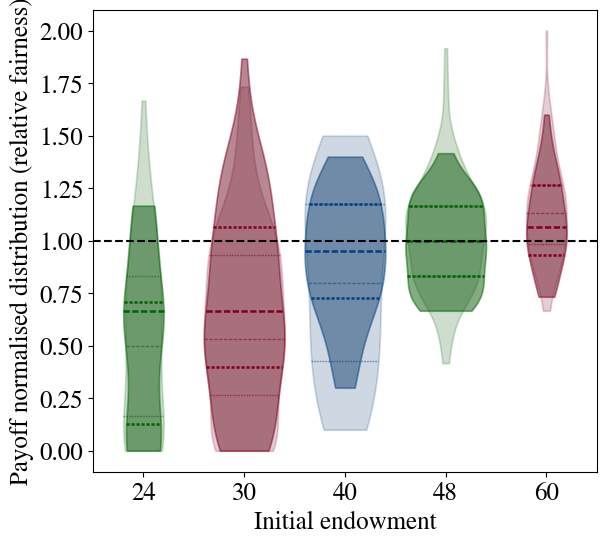

Saved: H1


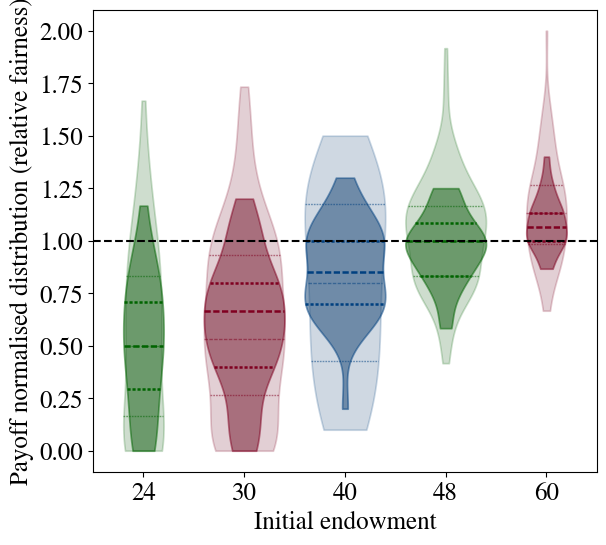

Saved: H2


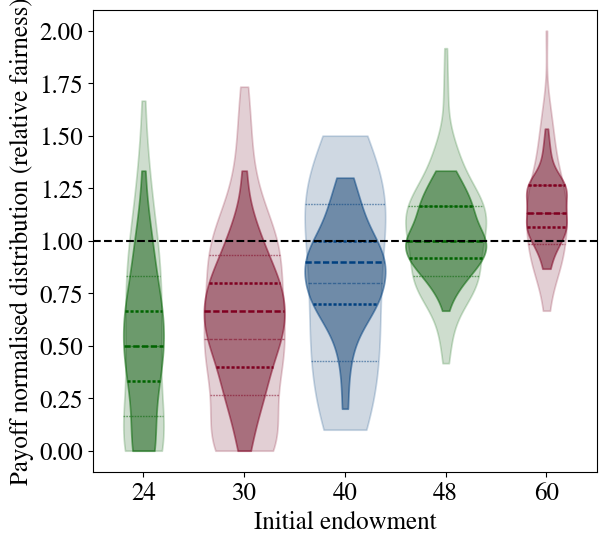

Saved: H3


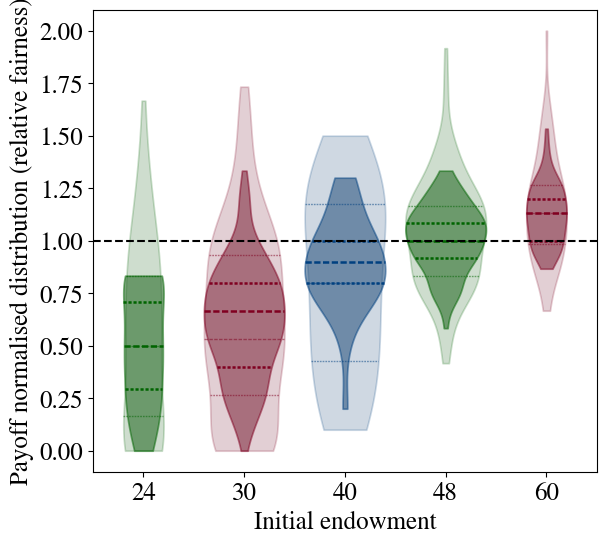

Saved: Hybridisation


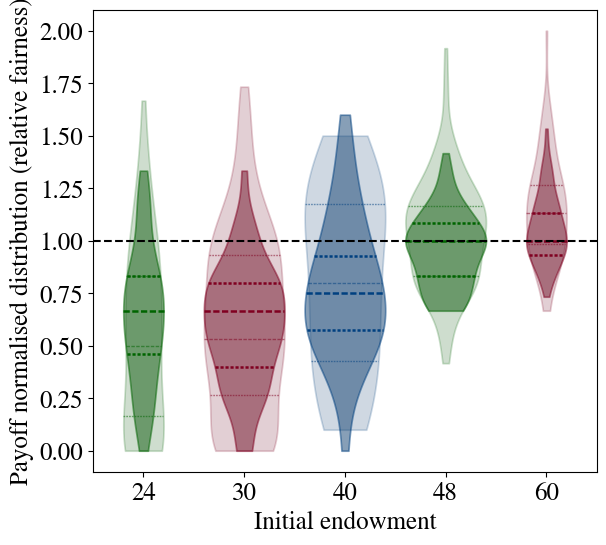

In [ ]:
# Compute normalized payoffs for real data
real_df = successful_users_six.copy()

# Output folder
output_folder = "Figures/SyntheticData/NormViolinPlotFinalPayoff/"
os.makedirs(output_folder, exist_ok=True)

x_labels = sorted(real_df['endowment_initial'].unique())
x_positions = range(len(x_labels))

for hypo, df_sim in simulated_dfs_success.items():
    sim_df = df_sim.copy()
    sim_df['normalized_payoff'] = sim_df['endowment_current'] / (0.5 * df_sim['endowment_initial'])

    plt.figure(figsize=(6.5, 6))
    ax = plt.gca()

    for control_wealth in real_df['control_wealth'].unique():
        color = wealth_colors[control_wealth]

        # Filter by control wealth
        subset_real = real_df[real_df['control_wealth'] == control_wealth]
        subset_sim = sim_df[sim_df['control_wealth'] == control_wealth]

        # Before plotting real
        collections_before_real = len(ax.collections)
        lines_before_real = len(ax.lines)
        # Plot real violins (gray outlines)
        sns.violinplot(
            data=subset_real,
            x='endowment_initial',
            y='normalized_payoff',
            order=x_labels,
            color=color,
            inner='quartile',
            cut=0,
            density_norm="count",
            common_norm=False,
            ax=ax
        )

        # After plotting synthetic
        collections_after_real = len(ax.collections)
        lines_after_real = len(ax.lines)

        # Modify only newly added collections (simulated)
        for patch in ax.collections[collections_before_real:collections_after_real]:
            patch.set_alpha(0.2)
            patch.set_edgecolor(color)
        # Modify only new lines (quartile/median of simulated)
        for line in ax.lines[lines_before_real:lines_after_real]:
            line.set_alpha(0.5)
            line.set_color(color)
            line.set_linewidth(1)

        # Before plotting synthetic
        collections_before = len(ax.collections)
        lines_before = len(ax.lines)
        # Plot synthetic violins (colored)
        sns.violinplot(
            data=subset_sim,
            x='endowment_initial',
            y='normalized_payoff',
            order=x_labels,
            color=color,
            inner='quartile',
            cut=0,
            density_norm="count",
            common_norm=False,
            ax=ax
        )

        # After plotting synthetic
        collections_after = len(ax.collections)
        lines_after = len(ax.lines)

        # Modify only newly added collections (simulated)
        for patch in ax.collections[collections_before:collections_after]:
            patch.set_alpha(0.5)
            patch.set_edgecolor(color)
        
        # Modify only new lines (quartile/median of simulated)
        for line in ax.lines[lines_before:lines_after]:
            line.set_color(color)
            line.set_linewidth(1.8)

    # Formatting
    ax.axhline(y=1, color='black', linestyle='dashed', linewidth=1.5)
    ax.set_xlabel("Initial endowment", fontsize=18)
    ax.set_ylabel("Payoff normalised distribution (relative fairness)", fontsize=18)
    ax.tick_params(labelcolor='black', labelsize=18)
    ax.set_ylim(-0.10, 2.10)
    ax.grid(False)
    ax.get_legend().remove() if ax.get_legend() else None

    plt.savefig(f"{output_folder}/NormViolinPlotFinalPayoffSUCCESS_{hypo}.pdf", bbox_inches='tight', pad_inches=0.2)
    print(f"Saved: {hypo}")
    plt.show()

Synthetic Lorenz curves and Gini coefficients for all treatment across hypotheses

Saved: ('H0', 'EQUAL')


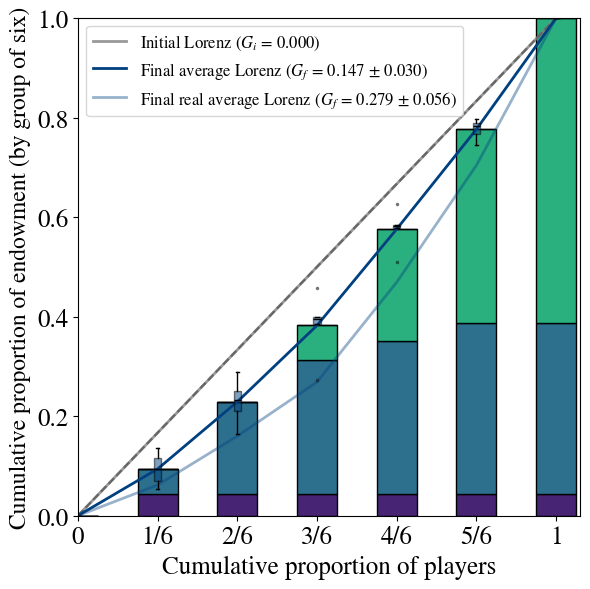

Saved: ('H0', 'UNEQUAL-L')


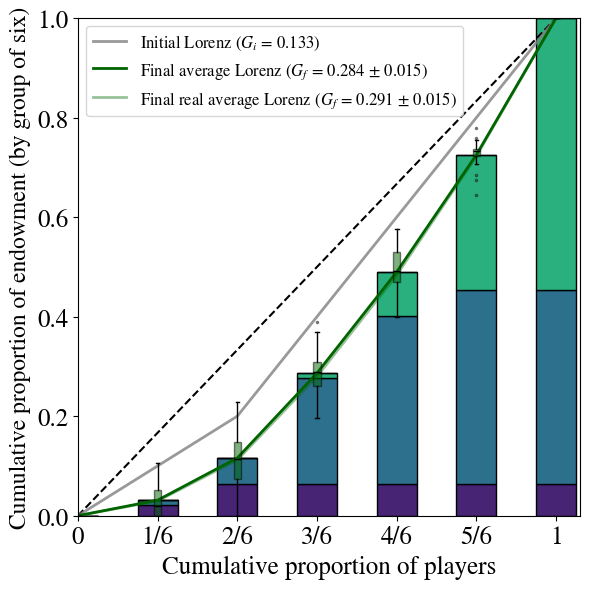

Saved: ('H0', 'UNEQUAL-H')


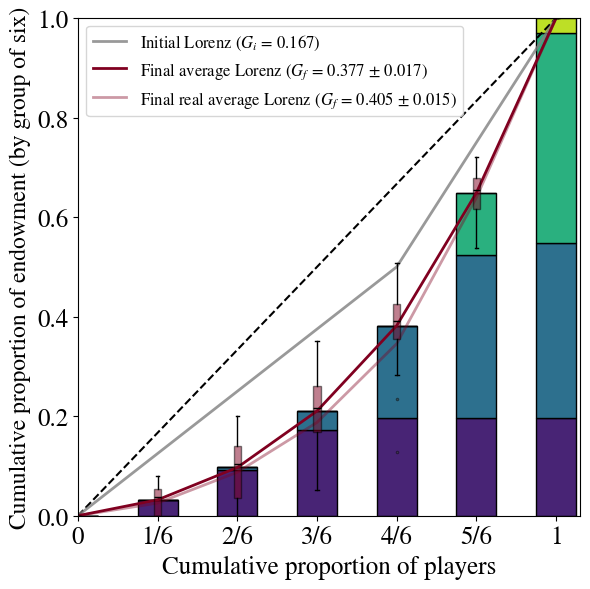

Saved: ('H1', 'EQUAL')


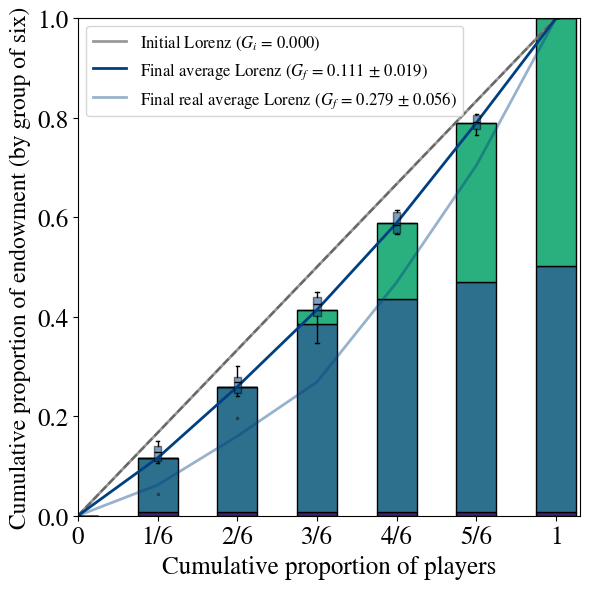

Saved: ('H1', 'UNEQUAL-L')


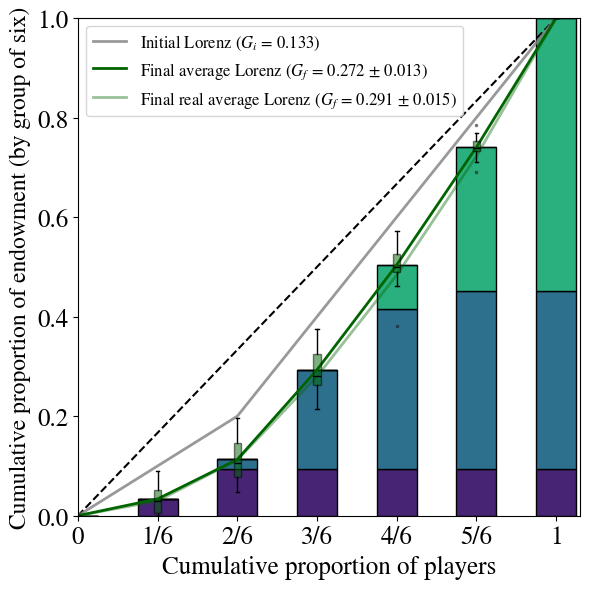

Saved: ('H1', 'UNEQUAL-H')


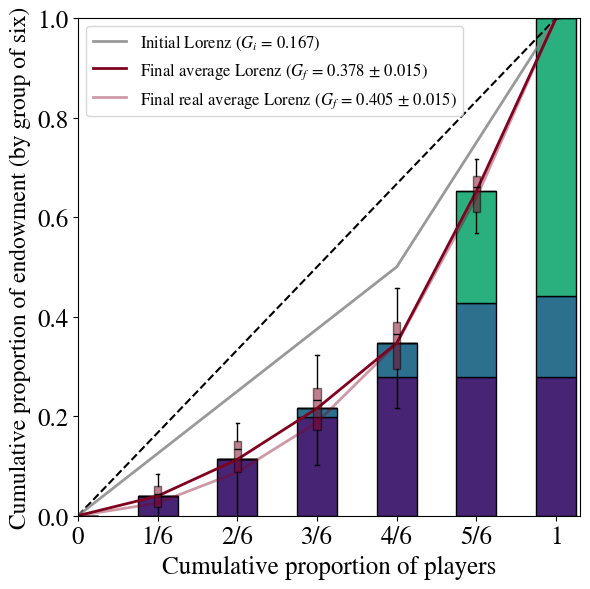

Saved: ('H2', 'EQUAL')


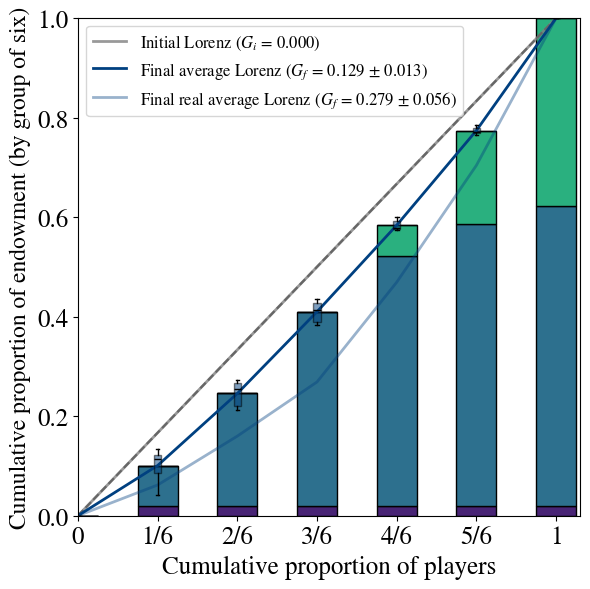

Saved: ('H2', 'UNEQUAL-L')


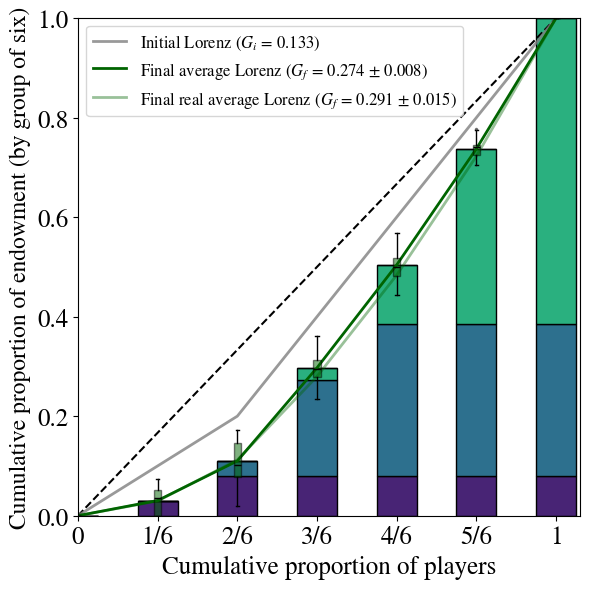

Saved: ('H2', 'UNEQUAL-H')


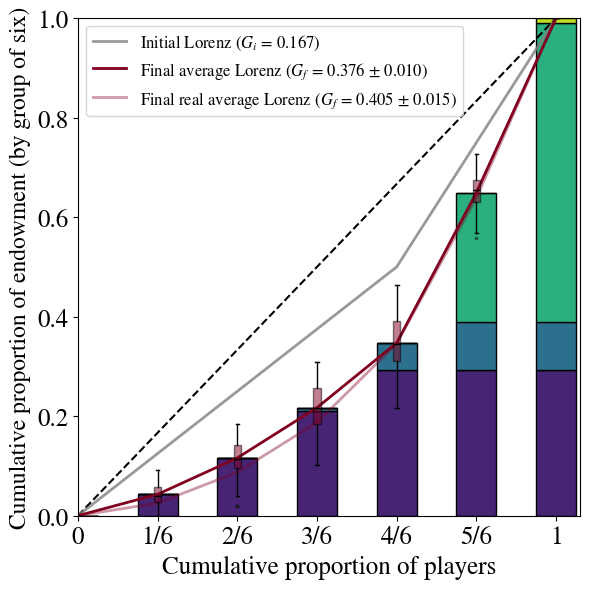

Saved: ('H3', 'EQUAL')


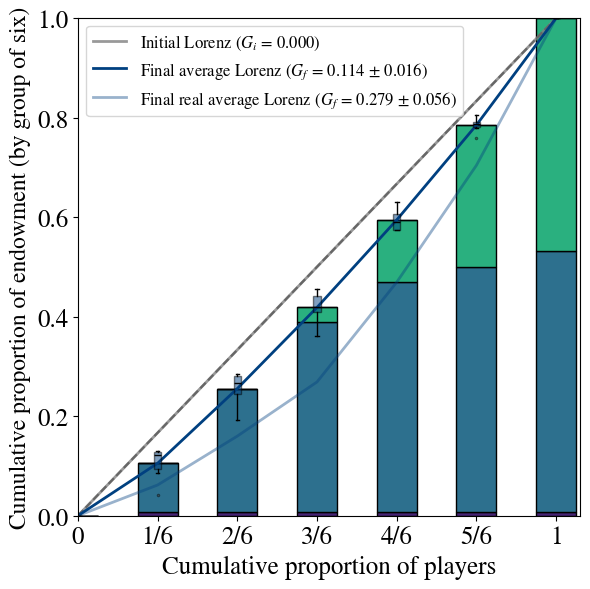

Saved: ('H3', 'UNEQUAL-L')


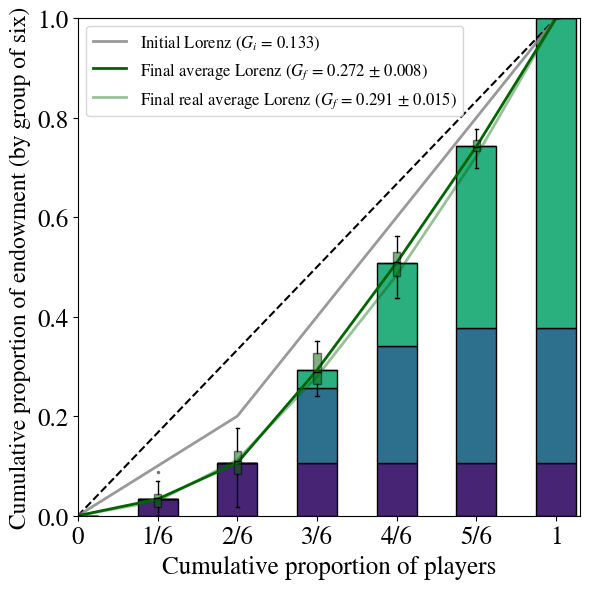

Saved: ('H3', 'UNEQUAL-H')


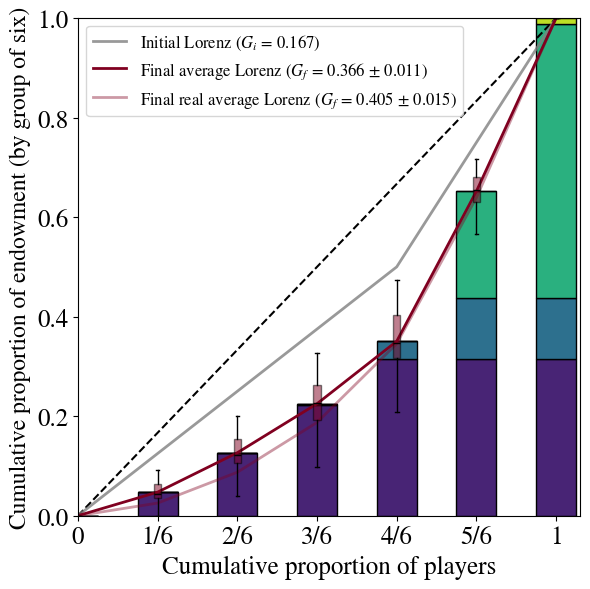

Saved: ('Hybridisation', 'EQUAL')


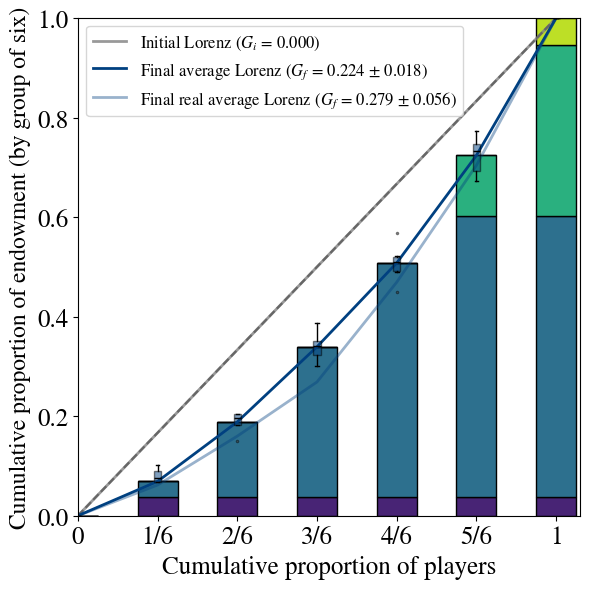

Saved: ('Hybridisation', 'UNEQUAL-L')


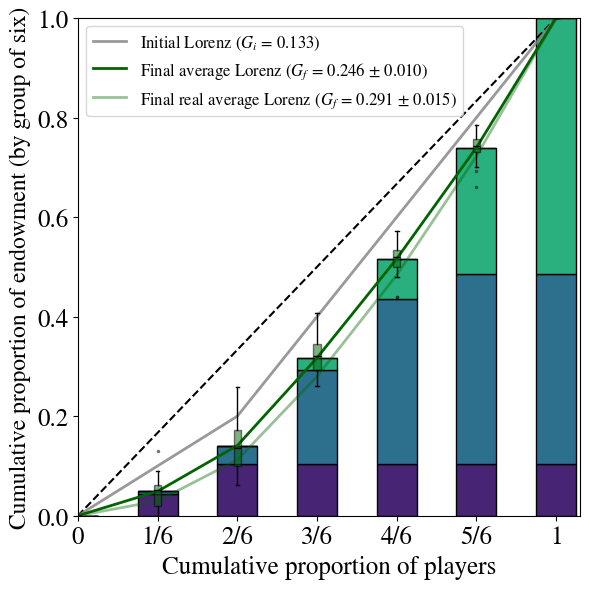

Saved: ('Hybridisation', 'UNEQUAL-H')


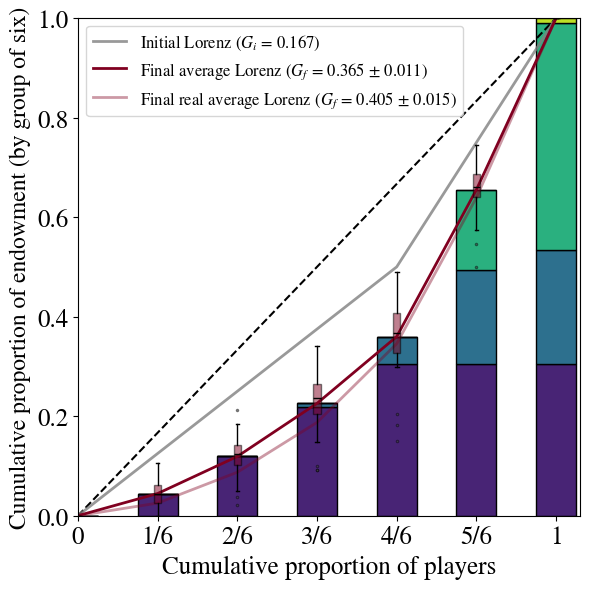

In [ ]:
output_folder = f"Figures/SyntheticData/LorenzQuartiles/"
os.makedirs(output_folder, exist_ok=True)

# Initialize storage
quartile_summary = {}

for hypo, df_sim in simulated_dfs_success.items():
    df = df_sim.copy()

    for control_wealth in df["control_wealth"].unique():
        # Real Lorenz (reference)
        df_sub_real = successful_users_six[successful_users_six["control_wealth"] == control_wealth]
        lorenz_final_curves_real = []
        gini_final_list_real = []

        for partida_id, group in df_sub_real.groupby("partida_id"):
            x_final = group["endowment_current"].values
            p_share, c_final = lorenz_curve(x_final)
            lorenz_final_curves_real.append(c_final)
            gini_final_list_real.append(gini_coeff(x_final))

        mean_final_real = np.mean(lorenz_final_curves_real, axis=0)
        gini_final_avg_real = np.nanmean(gini_final_list_real)
        gini_final_err_real = np.nanstd(gini_final_list_real, ddof=1) / np.sqrt(len(gini_final_list_real))

        # Synthetic Lorenz
        df_sub = df[df["control_wealth"] == control_wealth].copy()
        max_endowment = df_sub["endowment_initial"].max()
        quartile_bins = [0.0, 0.25 * max_endowment, 0.5 * max_endowment, 0.75 * max_endowment, max_endowment + 1e-6]
        quartile_labels = ['Q1', 'Q2', 'Q3', 'Q4']
        quartile_palette = cm.viridis(np.linspace(0.1, 0.9, len(quartile_labels)))
        quartile_color_map = dict(zip(quartile_labels, quartile_palette))

        lorenz_init_curves = []
        gini_init_list = []
        lorenz_final_curves = []
        gini_final_list = []
        stacked_quartile_contributions = {q: [] for q in quartile_labels}

        for partida_id, group in df_sub.groupby("partida_id"):
            x_init = group["endowment_initial"].values
            x_final = group["endowment_current"].values
            p_share, c_init = lorenz_curve(x_init)
            p_share, c_final = lorenz_curve(x_final)

            lorenz_init_curves.append(c_init)
            lorenz_final_curves.append(c_final)
            gini_init_list.append(gini_coeff(x_init))
            gini_final_list.append(gini_coeff(x_final))

            quartile_indices = pd.cut(x_final, bins=quartile_bins, labels=quartile_labels, include_lowest=True, right=False)
            df_quartile = pd.DataFrame({'income': x_final, 'quartile': quartile_indices}).sort_values('income')

            income = df_quartile['income'].values
            total = income.sum()
            stacked_q = np.zeros((len(p_share), len(quartile_labels)))

            for i, val in enumerate(income):
                q = df_quartile.iloc[i]['quartile']
                idx = quartile_labels.index(q)
                if total > 0:
                    stacked_q[i+1, idx] = val / total
                else:
                    stacked_q[i+1, idx] = 1 / len(quartile_labels)

            stacked_q = np.cumsum(stacked_q, axis=0)
            for j, q in enumerate(quartile_labels):
                stacked_quartile_contributions[q].append(stacked_q[:, j])

        mean_init = np.mean(lorenz_init_curves, axis=0)
        mean_final = np.mean(lorenz_final_curves, axis=0)
        sem_final = np.std(lorenz_final_curves, axis=0, ddof=1) / np.sqrt(len(lorenz_final_curves))
        gini_init_avg = np.nanmean(gini_init_list)
        gini_final_avg = np.nanmean(gini_final_list)
        gini_final_err = np.nanstd(gini_final_list, ddof=1) / np.sqrt(len(gini_final_list))

        avg_contrib = {q: np.mean(stacked_quartile_contributions[q], axis=0) for q in quartile_labels}

        # Save final values
        quartile_summary[(control_wealth, hypo)] = {q: avg_contrib[q][-1] for q in quartile_labels}

        # Plot
        plt.figure(figsize=(6, 6))
        plt.plot([0, 1], [0, 1], color='black', linestyle='--')

        plt.plot(p_share, mean_init, label=f"Initial Lorenz ($G_i$ = {gini_init_avg:.3f})",
                 color='gray', linewidth=2, alpha=0.8)

        plt.plot(p_share, mean_final, label=f"Final average Lorenz ($G_f$ = {gini_final_avg:.3f} ± {gini_final_err:.3f})",
                 color=wealth_colors[control_wealth], linewidth=2)

        plt.plot(p_share, mean_final_real, label=f"Final real average Lorenz ($G_f$ = {gini_final_avg_real:.3f} ± {gini_final_err_real:.3f})",
                 color=wealth_colors[control_wealth], linewidth=2, alpha=0.4)

        # Boxplot
        positions = p_share
        lorenz_final_curves = np.array(lorenz_final_curves)
        data_to_plot = [lorenz_final_curves[:, i] for i in range(len(p_share))]
        plt.boxplot(data_to_plot,
                    positions=positions,
                    widths=0.015,
                    patch_artist=True,
                    boxprops=dict(facecolor=wealth_colors[control_wealth], color='black', alpha=0.5),
                    medianprops=dict(color='black'),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    flierprops=dict(marker='.', markerfacecolor='gray', markersize=3, linestyle='none', alpha=0.5))

        # Stacked quartiles
        bottom = np.zeros_like(p_share)
        for q in quartile_labels:
            vals = avg_contrib[q]
            plt.bar(p_share, vals, bottom=bottom, width=1/12, align='center',
                    color=quartile_color_map[q], edgecolor='black')
            bottom += vals

        plt.xticks(p_share, ["0","1/6","2/6","3/6","4/6","5/6","1"], fontsize=18)
        plt.yticks(fontsize=18)
        plt.xlabel("Cumulative proportion of players", fontsize=18)
        plt.ylabel("Cumulative proportion of endowment (by group of six)", fontsize=17)
        plt.xlim(0, 1.05)
        plt.ylim(0, 1.001)
        plt.legend(fontsize=12, loc="upper left")
        plt.tight_layout()
        filename = f"{output_folder}/LorenzQuartiles_{str(control_wealth)}_{hypo}.pdf"
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.2)
        print(f"Saved: {hypo, control_wealth}")
        plt.show()

Synthetic fair deviations from experimental contribution over rounds across hypotheses

Saved: H0


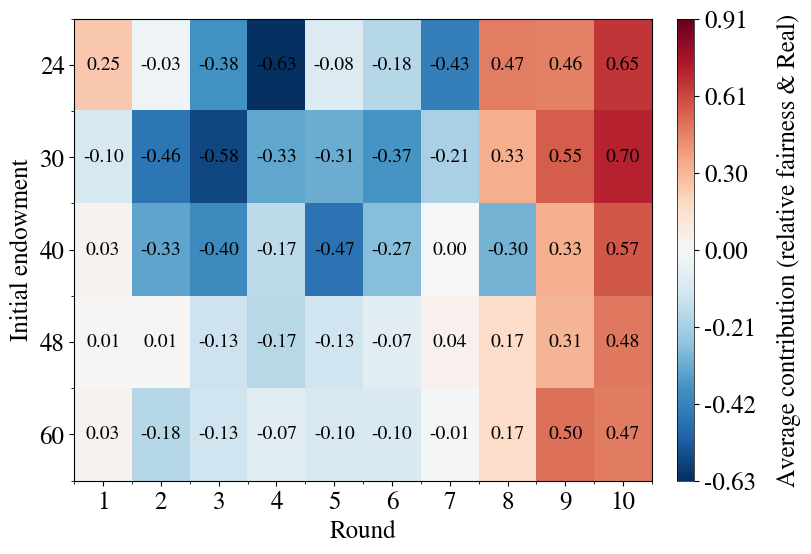

Saved: H1


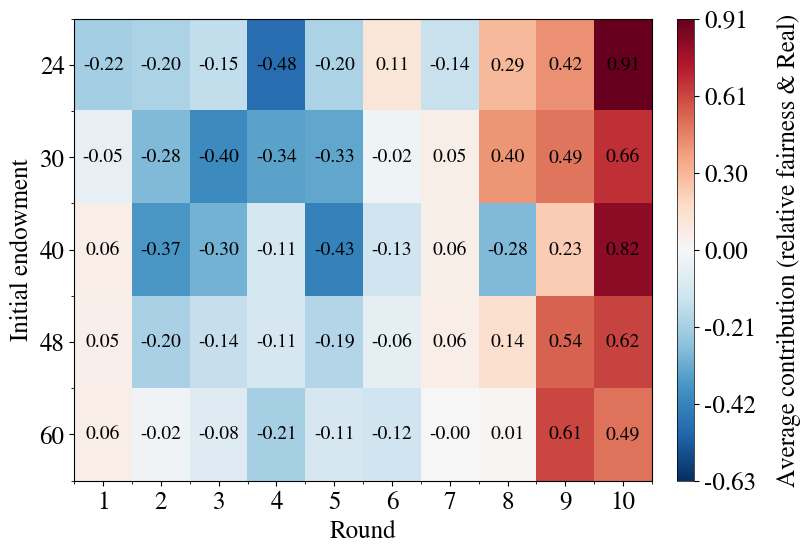

Saved: H2


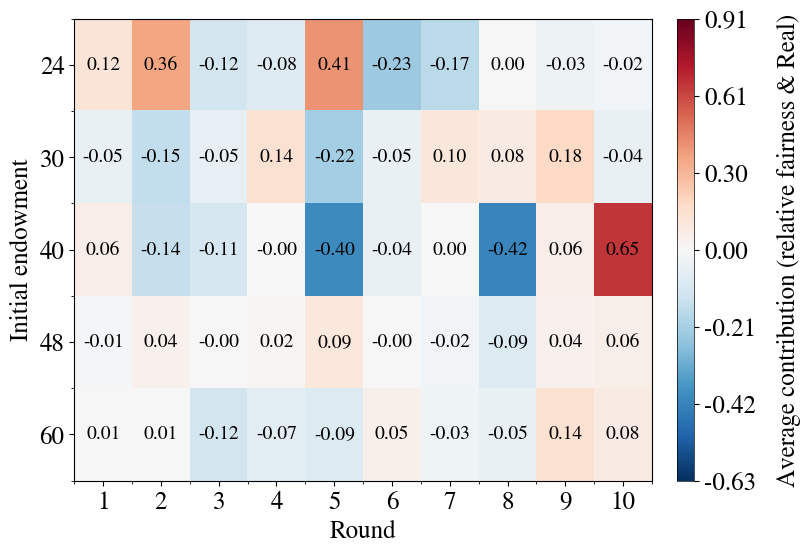

Saved: H3


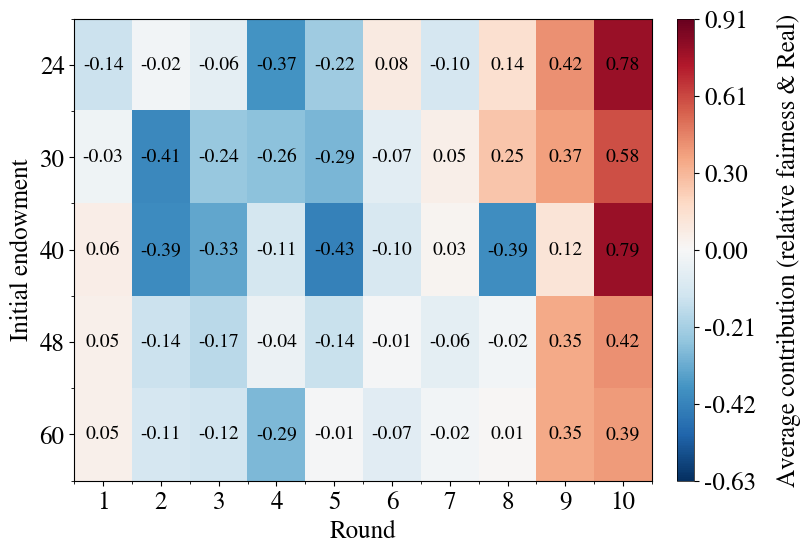

Saved: Hybridisation


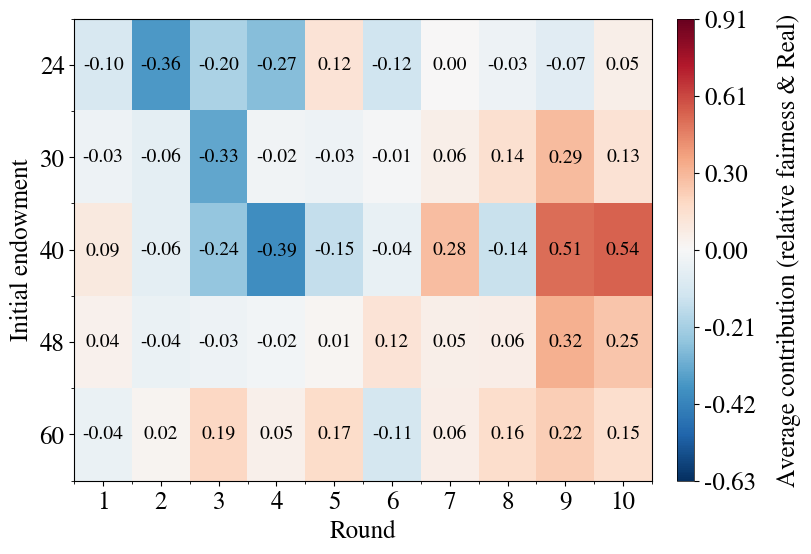

In [ ]:
# Ensure the folder exists
output_folder = f"Figures/SyntheticData/AverageContributionRound/"
os.makedirs(output_folder, exist_ok=True)

# Placeholder for average contribution results
average_contribution_results_real = []

df=successful_users_six.copy()

# Iterate over games (partida_id)
for partida_id, game_data in df.groupby("partida_id"):
    for round_index, round_col in enumerate(round_columns):
        for endowment, endowment_data in game_data.groupby("endowment_initial"):
            avg_contribution = endowment_data[round_col].mean()  # Average contribution for this endowment in this round

            average_contribution_results_real.append({
                "partida_id": partida_id,
                "control_wealth": game_data["control_wealth"].iloc[0],
                "endowment_initial": endowment,
                "round": round_col,
                "average_contribution": avg_contribution/(0.5*endowment/10)
            })

# Convert to DataFrame
df_avg_contrib = pd.DataFrame(average_contribution_results_real)

# Compute average contributions for each `endowment_initial` and `round`
avg_contribution_matrix_real = df_avg_contrib.groupby(
    ["endowment_initial", "round"]
)["average_contribution"].mean().unstack()
# Reorder columns to ensure rounds are in the correct order
avg_contribution_matrix_real = avg_contribution_matrix_real[['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10']]

for hypo, df_sim in simulated_dfs_success.items():

    # Placeholder for average contribution results
    average_contribution_results = []
    
    sim_df = df_sim.copy()
    
    # Iterate over games (partida_id)
    for partida_id, game_data in sim_df.groupby("partida_id"):
        for round_index, round_col in enumerate(round_columns):
            for endowment, endowment_data in game_data.groupby("endowment_initial"):
                avg_contribution = endowment_data[round_col].mean()  # Average contribution for this endowment in this round
    
                average_contribution_results.append({
                    "partida_id": partida_id,
                    "control_wealth": game_data["control_wealth"].iloc[0],
                    "endowment_initial": endowment,
                    "round": round_col,
                    "average_contribution": avg_contribution/(0.5*endowment/10)
                })
    
    # Convert to DataFrame
    df_avg_contrib = pd.DataFrame(average_contribution_results)
    
    # Compute average contributions for each `endowment_initial` and `round`
    avg_contribution_matrix = df_avg_contrib.groupby(
        ["endowment_initial", "round"]
    )["average_contribution"].mean().unstack()
    # Reorder columns to ensure rounds are in the correct order
    avg_contribution_matrix = avg_contribution_matrix[['R1', 'R2', 'R3', 'R4', 'R5', 'R6', 'R7', 'R8', 'R9', 'R10']]

    #NORMALIZING UNDER REAL MATRIX CONTRIBUTIONS
    avg_contribution_matrix=avg_contribution_matrix-avg_contribution_matrix_real
    
    # Create heatmap using Matplotlib
    fig, ax = plt.subplots(figsize=(8, 6))

    min_height=-0.63
    max_height=0.91
    midpoint = 0 # Value at which white color will be centered
    norm = colors.TwoSlopeNorm(vmin=min_height, vcenter=midpoint, vmax=max_height)
    cmap = plt.colormaps.get_cmap('RdBu_r')
    
    # Plot the heatmap with vmin and vmax fixed
    ax.imshow(avg_contribution_matrix, cmap=cmap, norm=norm, aspect="auto",origin="upper", interpolation="nearest")
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='3%', pad=0.25)
    colorbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                 cax=cax, orientation='vertical', label='Simpson-Citywide')
    colorbar.ax.tick_params(labelsize=18)
    colorbar.set_label('Average contribution (relative fairness & Real)', fontsize=18, labelpad=15)
    
    # Set the number of ticks on the colorbar
    num_ticks = 3  # This gives you 2 positive ticks + 0 + 2 negative ticks
    positive_ticks = np.linspace(midpoint, max_height, num=num_ticks+1)[1:]  # Exclude 0 for positive ticks
    negative_ticks = np.linspace(min_height, midpoint, num=num_ticks+1)[:-1]  # Exclude 0 for negative ticks
    
    # Concatenate negative ticks, zero, and positive ticks
    tick_values = np.concatenate([negative_ticks, [midpoint], positive_ticks])    
    tick_labels = [f'{tick:.2f}' for tick in tick_values]
    
    colorbar.set_ticks(tick_values)
    colorbar.set_ticklabels(tick_labels)
    colorbar.outline.set_linewidth(0.5)  # Adjust the linewidth as needed
    
    # Ensure correct label alignment
    x_labels = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
    ax.set_xticks(np.arange(len(round_columns)))
    ax.set_xticklabels(x_labels)#, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(avg_contribution_matrix.index)))
    ax.set_yticklabels(avg_contribution_matrix.index)
    
    # Remove white grid lines
    ax.set_xticks(np.arange(-0.5, len(x_labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(avg_contribution_matrix.index), 1), minor=True)
    ax.grid(False, which="both")  # Remove grid lines
    ax.tick_params(labelcolor='black', labelsize=18)
    # Annotate the values (ensuring correct alignment)
    for i in range(len(avg_contribution_matrix.index)):  # Iterate over rows
        for j in range(len(round_columns)):  # Iterate over columns
            value = avg_contribution_matrix.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=14)
    
    # Labels and title
    ax.set_xlabel("Round", fontsize=18)
    ax.set_ylabel("Initial endowment", fontsize=18)
    
    plt.savefig(f"{output_folder}/AverageContributionRoundSUCCESSFAIRREAL_{hypo}.pdf", bbox_inches='tight', pad_inches=0.1)
    # Show plot
    print(f"Saved: {hypo}")
    plt.show()

Synthetic common fund evolution across hypotheses

Saved combined plot with inset for: H0


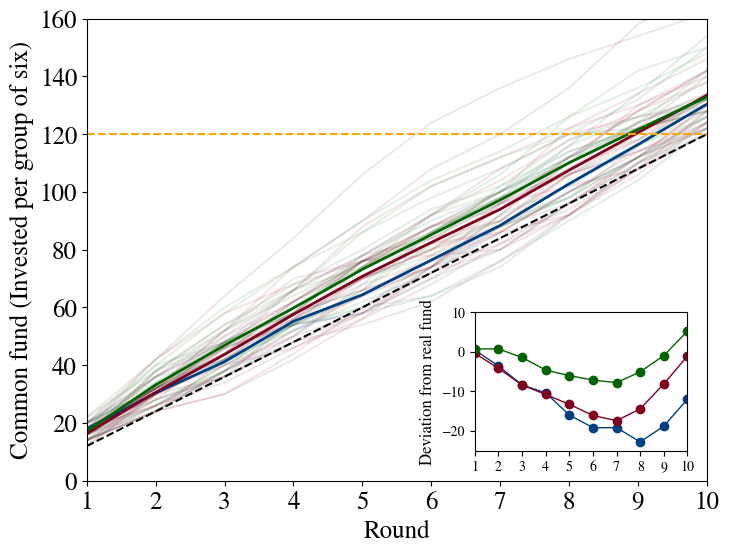

Saved combined plot with inset for: H1


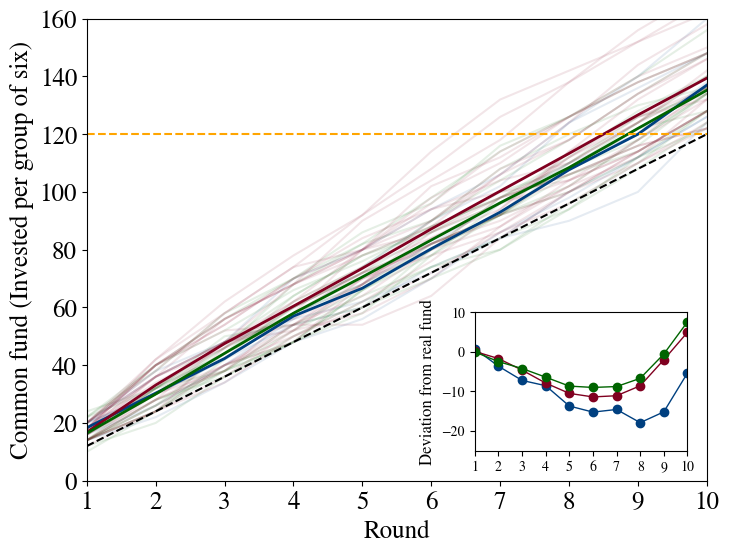

Saved combined plot with inset for: H2


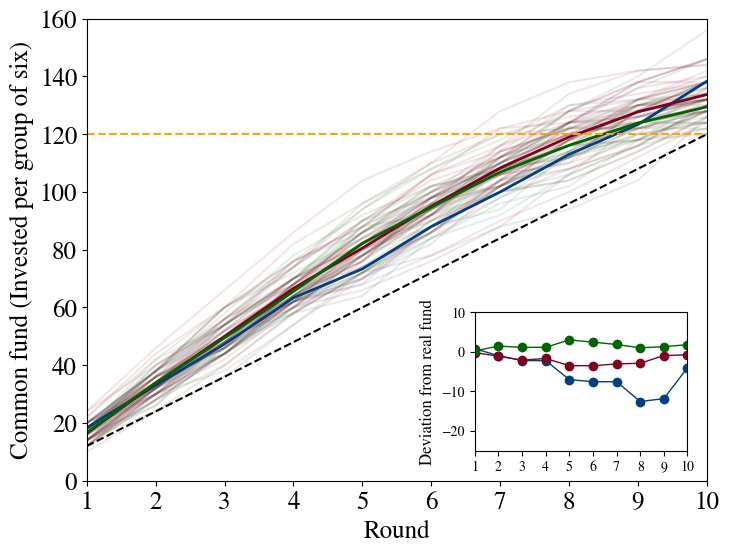

Saved combined plot with inset for: H3


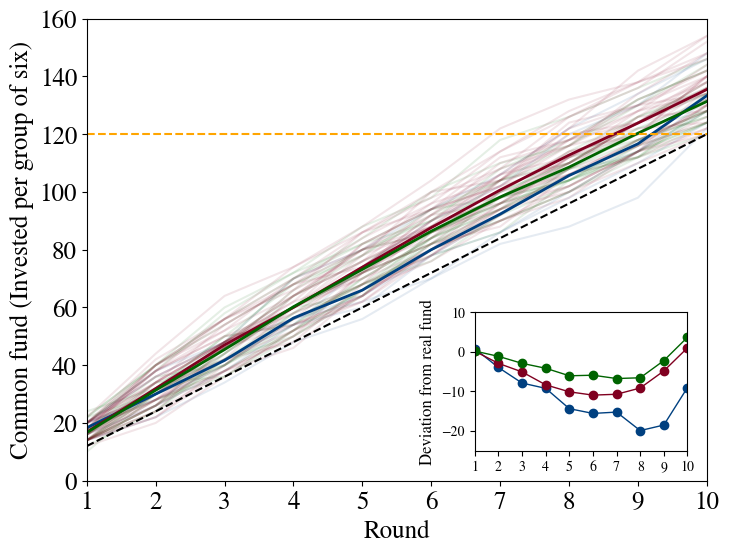

Saved combined plot with inset for: Hybridisation


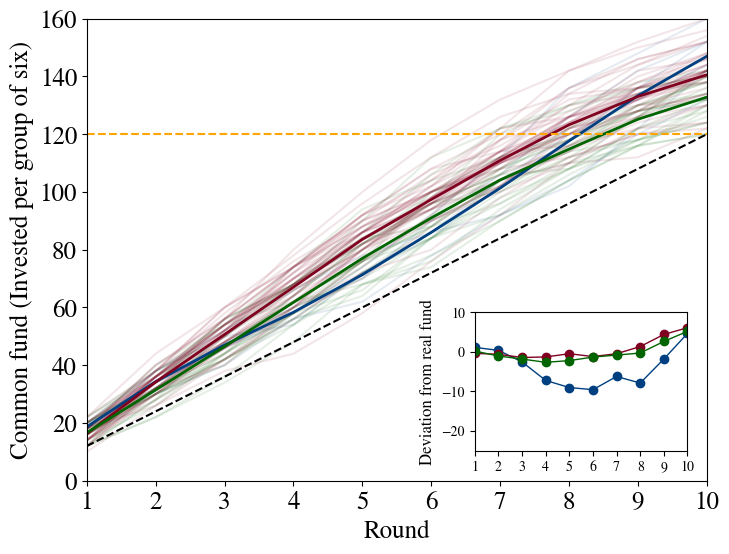

In [ ]:
output_folder = f"Figures/SyntheticData/CumulativePOTWealth/"
os.makedirs(output_folder, exist_ok=True)

# Placeholder for storing the round where each partida_id reaches the goal
cumulative_results = []

df=successful_users_six.copy()

# Iterate over games (partida_id)
for partida_id, game_data in df.groupby("partida_id"):
    cumulative_round = {}  # Track cumulative contribution over rounds
    cumulative_contribution = 0  # Track cumulative contribution over rounds

    for round_index, round_col in enumerate(round_columns):
        # Update cumulative contribution for all players up to this round
        cumulative_contribution += game_data[round_col].sum()
        cumulative_round[f"R{round_index + 1}"] = cumulative_contribution
    # Store the result for each control wealth
    cumulative_results.append({
        "partida_id": partida_id,
        "control_wealth": game_data["control_wealth"].iloc[0],
        **cumulative_round
    })

# Convert to DataFrame
df_cumulative = pd.DataFrame(cumulative_results)

# Ensure `df_cumulative` contains necessary columns
df_games_rounds = df_cumulative[['control_wealth'] + round_columns]

# Group by control_wealth and calculate the mean target distance per round.
mean_target_distance_real = df_games_rounds.groupby('control_wealth').mean()

for hypo, df_sim in simulated_dfs_success.items():

    df = df_sim.copy()

    cumulative_results = []

    for partida_id, game_data in df.groupby("partida_id"):
        cumulative_round = {}
        cumulative_contribution = 0

        for round_index, round_col in enumerate(round_columns):
            cumulative_contribution += game_data[round_col].sum()
            cumulative_round[f"R{round_index + 1}"] = cumulative_contribution

        cumulative_results.append({
            "partida_id": partida_id,
            "control_wealth": game_data["control_wealth"].iloc[0],
            **cumulative_round
        })

    df_cumulative = pd.DataFrame(cumulative_results)
    df_games_rounds = df_cumulative[['control_wealth'] + round_columns]
    mean_target_distance = df_games_rounds.groupby('control_wealth').mean()
    
    # Create main figure
    fig, ax_main = plt.subplots(figsize=(8, 6))

    # Plot individual transparent lines
    for _, row in df_games_rounds.iterrows():
        wealth_type = row["control_wealth"]
        ax_main.plot(range(1, 11), row[round_columns], color=wealth_colors[wealth_type], alpha=0.1)

    # Plot mean trajectories
    for wealth_type in mean_target_distance.index:
        ax_main.plot(range(1, 11), mean_target_distance.loc[wealth_type], label=f'{wealth_type}', 
                     color=wealth_colors[wealth_type], linewidth=2)

    # Reference lines
    ax_main.axhline(y=120, color='orange', linestyle='dashed', linewidth=1.5, label="Goal")
    ax_main.plot(range(1, 11), np.linspace(12, 120, 10), color='black', linestyle='dashed', linewidth=1.5, label="Cumulative fair contribution")

    # Formatting main plot
    ax_main.set_xlabel("Round", fontsize=18)
    ax_main.set_ylabel("Common fund (Invested per group of six)", fontsize=18)
    ax_main.tick_params(labelcolor='black', labelsize=18)
    ax_main.set_xticks(range(1, 11))
    ax_main.set_yticks(range(0, 180, 20))
    ax_main.set_ylim(0, 160)
    ax_main.set_xlim(1, 10)

    ax_inset = inset_axes(ax_main, width="35%", height="30%", loc="lower right", 
                      bbox_to_anchor=(0, 0.05, 0.98, 1), bbox_transform=ax_main.transAxes)

    # Mean distance to real goal (offset calculation)
    mean_target_distance_offset = df_games_rounds.groupby('control_wealth').mean() - mean_target_distance_real

    for wealth_type in mean_target_distance_offset.index:
        ax_inset.plot(range(1, 11), mean_target_distance_offset.loc[wealth_type], label=f'{wealth_type}', 
                      color=wealth_colors[wealth_type], linewidth=1, marker='o')

    ax_inset.set_ylabel("Deviation from real fund", fontsize=12)
    ax_inset.tick_params(labelsize=10)
    ax_inset.set_xticks(range(1, 11))
    ax_inset.set_xlim(1, 10)
    ax_inset.set_ylim(-25, 10)

    # Save and show
    plt.savefig(f"{output_folder}/CumulativePOTWealthSUCCESSREALInset_{hypo}.pdf", bbox_inches='tight', pad_inches=0.1)
    print(f"Saved combined plot with inset for: {hypo}")
    plt.show()